### Importing Packages

In [74]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

### Load the Dataset

In [75]:
df=pd.read_csv('G:/01 Data Analyst/Python+EDA/Project 1/netflix_titles.csv')

In [76]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### Check the datasets

In [77]:
df.shape

(8807, 12)

In [78]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


### Check for missing Values

In [80]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

### Check for Duplicate rows

In [81]:
df.duplicated().sum()

0

### Data Cleaning 

In [82]:
# Handling Missing Values 

In [83]:
df['director'] = df['director'].fillna('Unknown')
df['country'] = df['country'].fillna("Unknown")

In [85]:
# Drop rows with missing values   (date_added,rating,duration)
df.dropna(subset=['rating','duration','date_added'],inplace=True)

In [86]:
df.isnull().sum()

show_id           0
type              0
title             0
director          0
cast            825
country           0
date_added        0
release_year      0
rating            0
duration          0
listed_in         0
description       0
dtype: int64

In [87]:
# Remove irrelevent columns
df.drop(columns='cast',inplace=True)
df.drop(columns='description',inplace=True)

In [88]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in'],
      dtype='object')

In [89]:
df.shape

(8790, 10)

In [90]:
# Convert 'date_added' to datetime
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())

In [91]:
# Add New Columns 
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8790 non-null   object        
 1   type          8790 non-null   object        
 2   title         8790 non-null   object        
 3   director      8790 non-null   object        
 4   country       8790 non-null   object        
 5   date_added    8790 non-null   datetime64[ns]
 6   release_year  8790 non-null   int64         
 7   rating        8790 non-null   object        
 8   duration      8790 non-null   object        
 9   listed_in     8790 non-null   object        
 10  year_added    8790 non-null   int32         
 11  month_added   8790 non-null   object        
dtypes: datetime64[ns](1), int32(1), int64(1), object(9)
memory usage: 858.4+ KB


In [95]:
# Saved clean Version
df.to_csv("netflix_cleaned_dataset.csv",index=False)
df.shape

(8790, 12)

### Exploratory Data Analysis (EDA)

##### Count of content by types


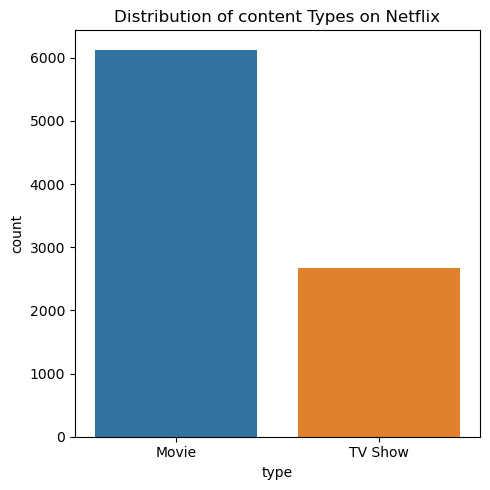

In [108]:
# plot size
plt.figure(figsize=(5,5))

# Create Graph
sns.countplot(x='type',data=df)

# title
plt.title("Distribution of content Types on Netflix")

plt.tight_layout()

plt.show()

##### Count of content by year

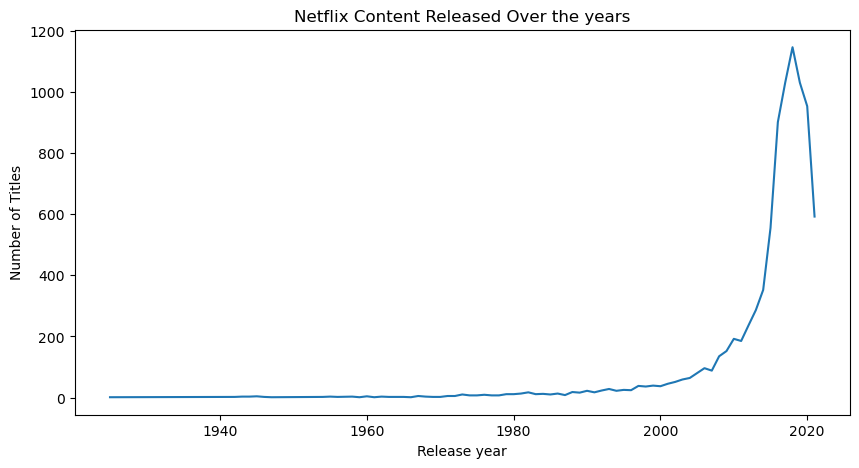

In [125]:
# Count
release_trend = df['release_year'].value_counts().sort_index()

# plot
plt.figure(figsize=(10,5))

sns.lineplot(x=release_trend.index,y=release_trend.values)

# plt.xticks(np.arange(1940,2025,10))

plt.title("Netflix Content Released Over the years")
plt.xlabel("Release year")
plt.ylabel("Number of Titles")

plt.show()

##### Count of Ratings

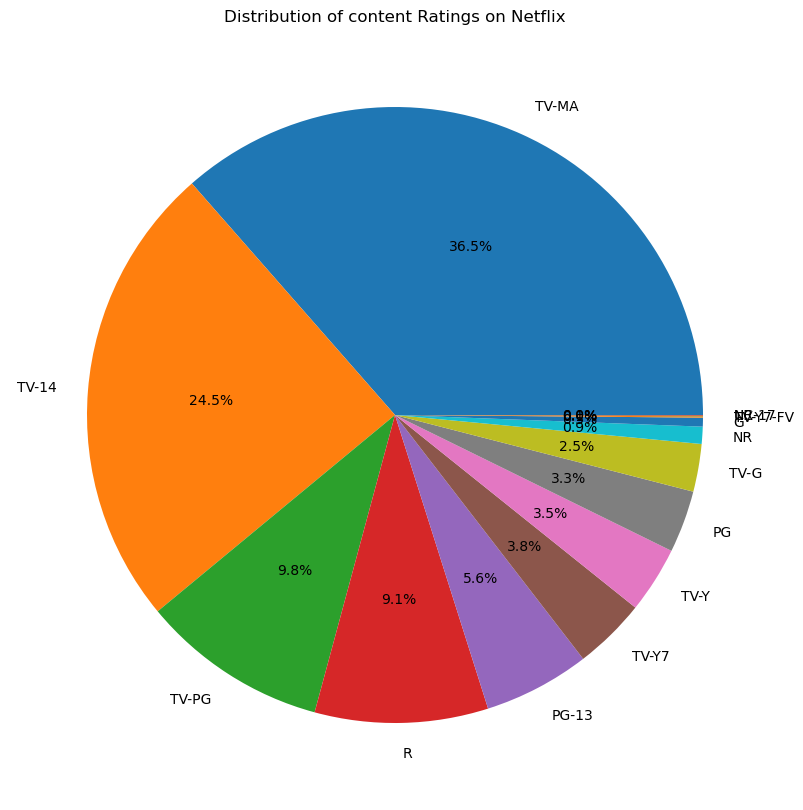

In [128]:
# Count values 
rating_counts=df['rating'].value_counts()

# plot 
plt.figure(figsize=(10,10))

plt.pie(rating_counts,labels=rating_counts.index,autopct='%1.1f%%')

plt.title("Distribution of content Ratings on Netflix")

plt.show()

#####  Count top 10 most featured directors on Netflix

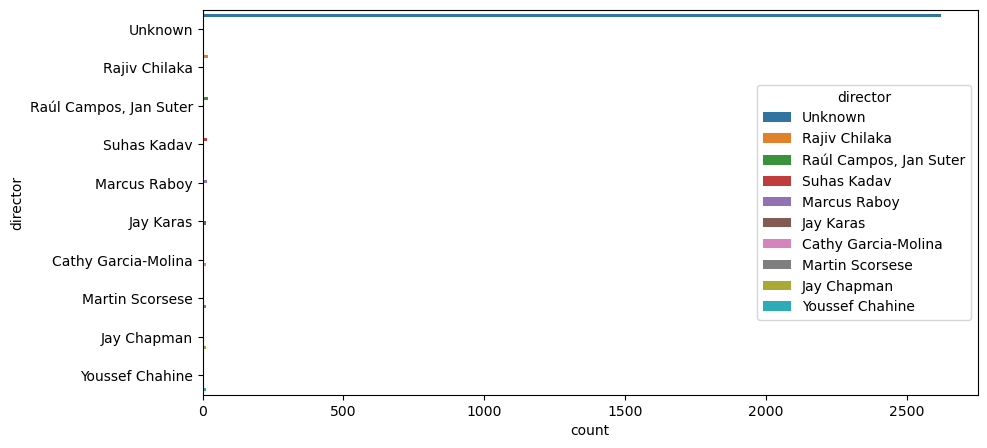

In [132]:
# Top 10 director
top_director = df['director'].value_counts().head(10).reset_index()
# reset_index is convert into data frame 
top_director.columns=['director','count']

# plot 
plt.figure(figsize=(10,5))

sns.barplot(data=top_director,x='count',y='director',hue='director')

plt.show()

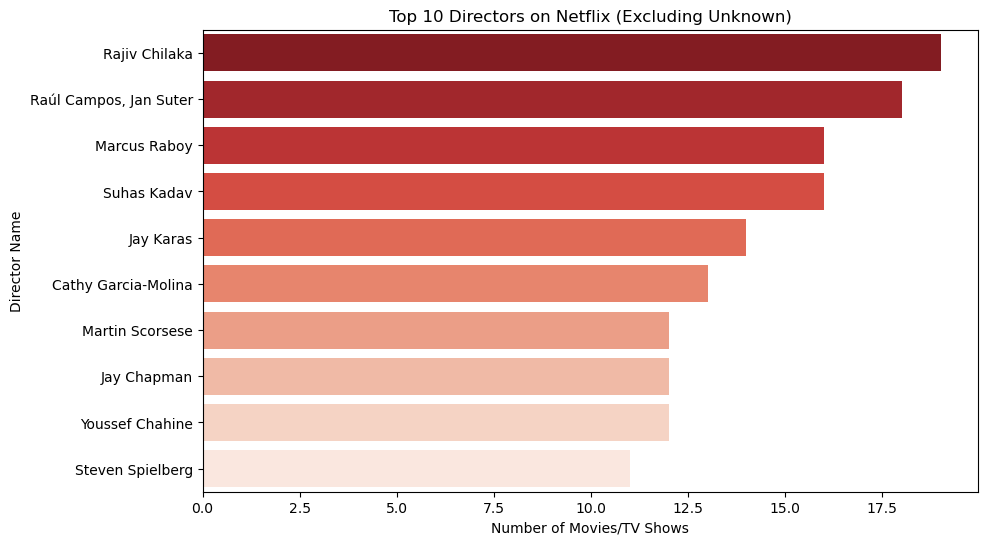

In [130]:
# 'Unknown' ko hata kar top 10 directors nikalein
filtered_directors = df[df['director'] != 'Unknown']
top_10_real = filtered_directors['director'].value_counts().head(10).reset_index()
top_10_real.columns = ['director', 'count']

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_real, x='count', y='director', palette='Reds_r')

plt.title('Top 10 Directors on Netflix (Excluding Unknown)')
plt.xlabel('Number of Movies/TV Shows')
plt.ylabel('Director Name')

plt.show()

##### Top 10 genres on Netflix

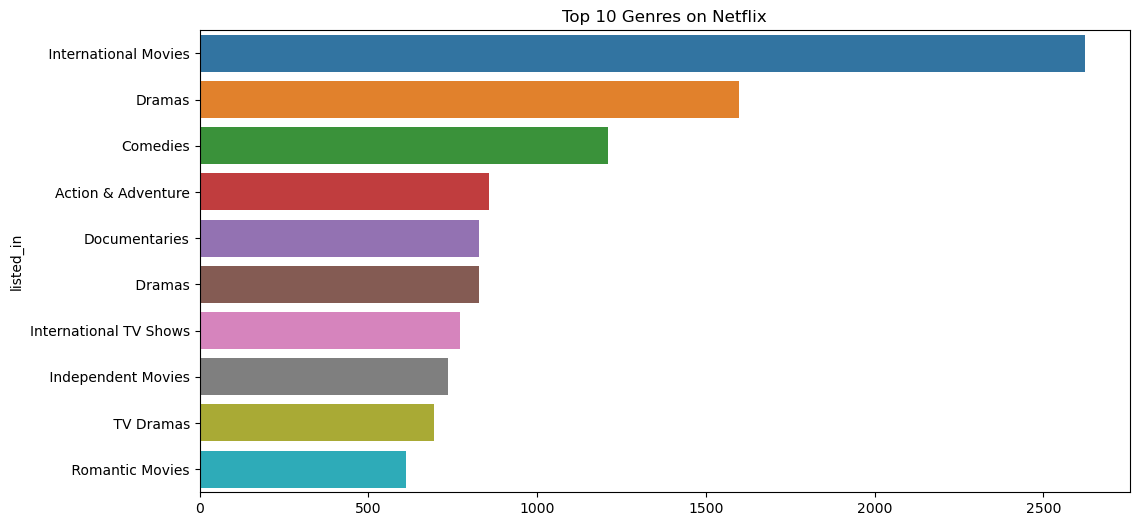

In [134]:
top_genres = df['listed_in'].str.split(',').explode().value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(x=top_genres.values,y=top_genres.index)

plt.title("Top 10 Genres on Netflix")
plt.show()

##### Country wise Content

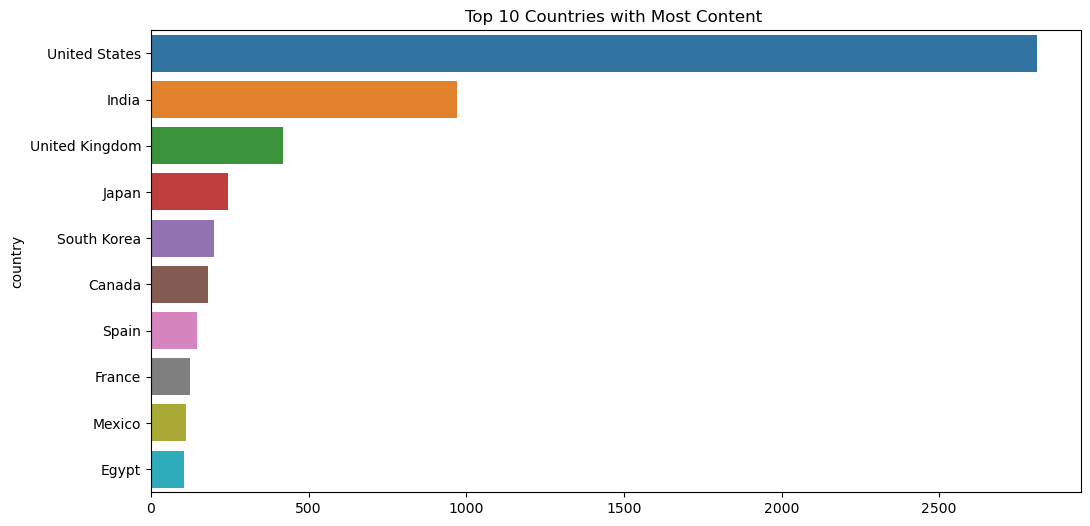

In [138]:
filter_country = df[df['country'] != 'Unknown']
top_10 = filter_country['country'].value_counts().head(10)
                        
plt.figure(figsize=(12,6))
                        
sns.barplot(x=top_10.values,y=top_10.index)
plt.title("Top 10 Countries with Most Content ")

plt.show()